# Reporte Visual — Pipeline Predictivo de Dominios Ferroeléctricos

Lee los resultados ya generados por los scripts de inferencia.
**No vuelve a correr inferencia. No carga modelos.**

Flujo:
1. `inferencia_regresion_C2.py`
2. `inferencia_regresion_C3.py`
3. `inferencia_segmentacion.py`
4. Este notebook → visualización interactiva


In [22]:
import os, csv, math, glob
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import torch
from IPython.display import display
from PIL import Image

matplotlib.rcParams['figure.dpi'] = 100
print("Imports ok")

Imports ok


## 1. Configuración


In [23]:
BASE_DIR = Path(r'C:\Users\migue\Desktop\modelo_predictivo')
DATA_DIR = BASE_DIR / 'data'
RES_DIR  = BASE_DIR / 'resultados'

# Training logs
SEG_LOG    = RES_DIR / 'modelo_segmentacion'  / 'training_log.csv'
RC2_LOG    = RES_DIR / 'modelo_regresion_C2'  / 'training_log.csv'
RC3_LOG    = RES_DIR / 'modelo_regresion_c3'  / 'training_log.csv'

# Checkpoints (solo para leer epoch y métrica, sin cargar modelo)
SEG_CKPT   = RES_DIR / 'modelo_segmentacion'  / 'checkpoints' / 'best_model.pth'
RC2_CKPT   = RES_DIR / 'modelo_regresion_C2'  / 'checkpoints' / 'best_model.pth'
RC3_CKPT   = RES_DIR / 'modelo_regresion_c3'  / 'checkpoints' / 'best_model.pth'

# Métricas de inferencia
SEG_MET_I  = RES_DIR / 'modelo_segmentacion'  / 'predicciones' / 'metricas_independiente.csv'
SEG_MET_A  = RES_DIR / 'modelo_segmentacion'  / 'predicciones' / 'metricas_autoregresiva.csv'
RC2_MET_I  = RES_DIR / 'modelo_regresion_C2'  / 'predicciones' / 'metricas_independiente.csv'
RC2_MET_A  = RES_DIR / 'modelo_regresion_C2'  / 'predicciones' / 'metricas_autoregresiva.csv'
RC3_MET_I  = RES_DIR / 'modelo_regresion_c3'  / 'predicciones' / 'metricas_independiente.csv'
RC3_MET_A  = RES_DIR / 'modelo_regresion_c3'  / 'predicciones' / 'metricas_autoregresiva.csv'

# Carpetas NPY de predicciones
SEG_NPY    = RES_DIR / 'modelo_segmentacion'  / 'predicciones' / 'npy'
RC2_NPY    = RES_DIR / 'modelo_regresion_C2'  / 'predicciones' / 'npy'
RC3_NPY    = RES_DIR / 'modelo_regresion_c3'  / 'predicciones' / 'npy'

# Modo de visualización: 'independiente' | 'autoregresiva'
MODO = 'independiente'

# Colores
BLUE='#378ADD'
ORANGE='#D85A30'
GREEN='#1D9E75'
PURPLE='#534AB7'
TEAL='#0F6E56'
GRAY='#888780'

print("Configuración cargada.")
print(f"  Modo visualización: {MODO}")

Configuración cargada.
  Modo visualización: independiente


## 2. Funciones auxiliares


In [24]:
def read_csv(path):
    if not Path(path).exists():
        print(f"  AVISO: no encontrado: {path}"); return []
    rows = []
    with open(str(path), 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            parsed = {}
            for k, v in row.items():
                try: parsed[k] = float(v)
                except ValueError: parsed[k] = v
            rows.append(parsed)
    return rows

def read_ckpt_info(path):
    if not Path(path).exists():
        print(f"  AVISO: checkpoint no encontrado: {path}"); return {}
    ckpt = torch.load(str(path), map_location='cpu')
    return {k: v for k, v in ckpt.items() if k != 'model_state'}

def load_npy(path, normalize=True):
    arr = np.load(str(path)).astype(np.float32)
    if normalize:
        mn, mx = arr.min(), arr.max()
        if mx - mn > 1e-8: arr = (arr - mn) / (mx - mn)
    return arr

def avg(lst, key):
    vals = [r[key] for r in lst if r.get(key) not in (None,'','None')]
    return round(sum(vals)/len(vals), 4) if vals else None

def avg_str(lst, key, fmt='.4f'):
    v = avg(lst, key)
    return f'{v:{fmt}}' if v is not None else 'N/A'

def cargar_inputs_frame(frame_num, has_gt=True):
    inp = frame_num - 1

    def _lnpy(path):
        a = np.load(str(path)).astype(np.float32)
        mn,mx = a.min(),a.max()
        if mx-mn>1e-8: a=(a-mn)/(mx-mn)
        return a

    def _real(folder, pos):
        lst = sorted(Path(folder).glob('*.npy'))
        return _lnpy(lst[pos-1]) if 0 < pos <= len(lst) else None

    def _find_prev(npy_dir, fn_prev):
        if npy_dir is None: return None
        for pat in [f'frame_{fn_prev:03d}_sin_gt_pred.npy',
                    f'frame_{fn_prev:03d}_indep_pred.npy',
                    f'frame_{fn_prev:03d}_auto_pred.npy']:
            c = list(Path(npy_dir/'pred').glob(pat))
            if c: return _lnpy(c[0])
        return None

    if not has_gt:
        # C2: predicho anterior
        c2_prev = _find_prev(RC2_NPY, inp)
        c2_input  = c2_prev if c2_prev is not None else _real(DATA_DIR/'canal_2', min(inp, len(sorted((DATA_DIR/'canal_2').glob('*.npy')))))
        c2_fuente = f'C2 predicho frame {inp}' if c2_prev is not None else f'C2 real frame {inp}'

        # C2_diff encadenado
        d_cands = list(Path(RC2_NPY/'diff_pred').glob(f'frame_{frame_num:03d}_sin_gt_diff_pred.npy'))
        c2_diff = _lnpy(d_cands[0]) if d_cands else _real(DATA_DIR/'diff',
                      min(inp, len(sorted((DATA_DIR/'diff').glob('*.npy')))))

        # C3: predicho continuo anterior (rc3, nunca mascara)
        c3_prev = _find_prev(RC3_NPY, inp)
        c3_input  = c3_prev if c3_prev is not None else _real(DATA_DIR/'canal_3', min(inp, len(sorted((DATA_DIR/'canal_3').glob('*.npy')))))
        c3_fuente = f'C3 pred frame {inp}' if c3_prev is not None else f'C3 real frame {inp}'
    else:
        c2_input  = _real(DATA_DIR/'canal_2', inp)
        c2_diff   = _real(DATA_DIR/'diff',    inp)
        c3_input  = _real(DATA_DIR/'canal_3', inp)
        c2_fuente = f'C2 real frame {inp}'
        c3_fuente = f'C3 real frame {inp}'

    return c2_input, c2_diff, c3_input, c2_fuente, c3_fuente, 'twilight'

def cargar_frames_modo(modo):
    sufijo = 'indep' if modo == 'independiente' else 'auto'
    def _ls(folder, pat): return sorted(Path(folder).glob(pat)) if Path(folder).exists() else []
    def _fn(p):
        try: return int(p.stem.split('_')[1])
        except: return 0
    def _l(p): return load_npy(p, normalize=True) if p else None
    def _l_err(p): return load_npy(p, normalize=False) if p else None

    # Archivos con GT
    ps_gt  = _ls(SEG_NPY/'pred',  f'*_{sufijo}_pred.npy')
    rs_gt  = _ls(SEG_NPY/'pred_con_gt',  f'*_{sufijo}_pred_con_gt.npy')
    es_gt  = _ls(SEG_NPY/'error', f'*_{sufijo}_error.npy')
    p2_gt  = _ls(RC2_NPY/'pred',  f'*_{sufijo}_pred.npy')
    r2_gt  = _ls(RC2_NPY/'pred_con_gt',  f'*_{sufijo}_pred_con_gt.npy')
    e2_gt  = _ls(RC2_NPY/'error', f'*_{sufijo}_error.npy')
    p3_gt  = _ls(RC3_NPY/'pred',  f'*_{sufijo}_pred.npy')
    r3_gt  = _ls(RC3_NPY/'pred_con_gt',  f'*_{sufijo}_pred_con_gt.npy')
    e3_gt  = _ls(RC3_NPY/'error', f'*_{sufijo}_error.npy')

    # Archivos sin GT
    ps_sgt = _ls(SEG_NPY/'pred', '*_sin_gt_pred.npy')
    p2_sgt = _ls(RC2_NPY/'pred', '*_sin_gt_pred.npy')
    p3_sgt = _ls(RC3_NPY/'pred', '*_sin_gt_pred.npy')

    frames = {}

    for i in range(min(len(ps_gt), len(p2_gt), len(p3_gt))):
        fn = _fn(ps_gt[i])
        frames[fn] = {
            'frame': fn, 'modo': modo, 'has_gt': True,
            'seg_pred': _l(ps_gt[i]),
            'seg_real': _l(rs_gt[i]) if i < len(rs_gt) else None,
            'seg_error':_l_err(es_gt[i]) if i < len(es_gt) else None,
            'rc2_pred': _l(p2_gt[i]),
            'rc2_real': _l(r2_gt[i]) if i < len(r2_gt) else None,
            'rc2_error':_l_err(e2_gt[i]) if i < len(e2_gt) else None,
            'rc3_pred': _l(p3_gt[i]),
            'rc3_real': _l(r3_gt[i]) if i < len(r3_gt) else None,
            'rc3_error':_l_err(e3_gt[i]) if i < len(e3_gt) else None,
        }

    for i in range(min(len(ps_sgt), len(p2_sgt), len(p3_sgt))):
        fn     = _fn(ps_sgt[i])
        fn_prev= fn - 1

        def _prev(npy_dir, fn_p):
            for pat in [f'frame_{fn_p:03d}_sin_gt_pred.npy',
                        f'frame_{fn_p:03d}_indep_pred.npy',
                        f'frame_{fn_p:03d}_auto_pred.npy']:
                c = list(Path(npy_dir/'pred').glob(pat))
                if c: return _l(c[0])
            return None

        sg = _l(ps_sgt[i]); s_prev = _prev(SEG_NPY, fn_prev)
        r2 = _l(p2_sgt[i]); r2_prev= _prev(RC2_NPY, fn_prev)
        r3 = _l(p3_sgt[i]); r3_prev= _prev(RC3_NPY, fn_prev)

        frames[fn] = {
            'frame': fn, 'modo': 'sin_gt', 'has_gt': False,
            'seg_pred': sg,
            'seg_real': s_prev,  # mascara anterior (binaria)
            'seg_error': np.abs(sg-s_prev) if sg is not None and s_prev is not None else None,
            'rc2_pred': r2,
            'rc2_real': r2_prev,
            'rc2_error': np.abs(r2-r2_prev) if r2 is not None and r2_prev is not None else None,
            'rc3_pred': r3,
            'rc3_real': r3_prev,
            'rc3_error': np.abs(r3-r3_prev) if r3 is not None and r3_prev is not None else None,
        }

    result = sorted(frames.values(), key=lambda x: x['frame'])
    n_gt  = sum(1 for f in result if f['has_gt'])
    n_sgt = sum(1 for f in result if not f['has_gt'])
    print(f"Frames cargados: {len(result)} total ({n_gt} con GT, {n_sgt} sin GT)")
    return result

def imshow_cb(ax, data, cmap, title, vmin=0, vmax=1):
    if data is None:
        ax.set_facecolor('#EEEEEE')
        ax.text(0.5,0.5,'no disponible',ha='center',va='center',
                fontsize=7,color='gray',transform=ax.transAxes)
    else:
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=8); ax.axis('off')

print("Funciones cargadas.")

Funciones cargadas.


## 3. Cargar datos desde disco


In [25]:
print("Leyendo training logs...")
seg_log = read_csv(SEG_LOG)
rc2_log = read_csv(RC2_LOG)
rc3_log = read_csv(RC3_LOG)
print(f"  Seg: {len(seg_log)} epochs | C2: {len(rc2_log)} epochs | C3: {len(rc3_log)} epochs")

print("\nLeyendo checkpoints (solo info, sin cargar modelo)...")
seg_ckpt = read_ckpt_info(SEG_CKPT)
rc2_ckpt = read_ckpt_info(RC2_CKPT)
rc3_ckpt = read_ckpt_info(RC3_CKPT)
print(f"  Seg  epoch={seg_ckpt.get('epoch','?')} val_iou={seg_ckpt.get('val_iou','?'):.4f}" if seg_ckpt.get('val_iou') else f"  Seg  {seg_ckpt}")
print(f"  C2   epoch={rc2_ckpt.get('epoch','?')} val_ssim={rc2_ckpt.get('val_ssim','?'):.4f}" if rc2_ckpt.get('val_ssim') else f"  C2   {rc2_ckpt}")
print(f"  C3   epoch={rc3_ckpt.get('epoch','?')} val_ssim={rc3_ckpt.get('val_ssim','?'):.4f}" if rc3_ckpt.get('val_ssim') else f"  C3   {rc3_ckpt}")

print("\nLeyendo métricas de inferencia...")
seg_i = read_csv(SEG_MET_I); seg_a = read_csv(SEG_MET_A)
rc2_i = read_csv(RC2_MET_I); rc2_a = read_csv(RC2_MET_A)
rc3_i = read_csv(RC3_MET_I); rc3_a = read_csv(RC3_MET_A)
print(f"  Seg  indep={len(seg_i)} | auto={len(seg_a)}")
print(f"  C2   indep={len(rc2_i)} | auto={len(rc2_a)}")
print(f"  C3   indep={len(rc3_i)} | auto={len(rc3_a)}")

print(f"\nCargando arrays NPY ({MODO})...")
frames_data = cargar_frames_modo(MODO)
print(f"  {len(frames_data)} frames cargados")

Leyendo training logs...
  Seg: 100 epochs | C2: 100 epochs | C3: 100 epochs

Leyendo checkpoints (solo info, sin cargar modelo)...
  Seg  epoch=67 val_iou=0.8305
  C2   epoch=96 val_ssim=0.7930
  C3   epoch=100 val_ssim=0.7778

Leyendo métricas de inferencia...
  Seg  indep=5 | auto=5
  C2   indep=5 | auto=5
  C3   indep=5 | auto=5

Cargando arrays NPY (independiente)...
Frames cargados: 10 total (5 con GT, 5 sin GT)
  10 frames cargados


## 4. Curvas de entrenamiento


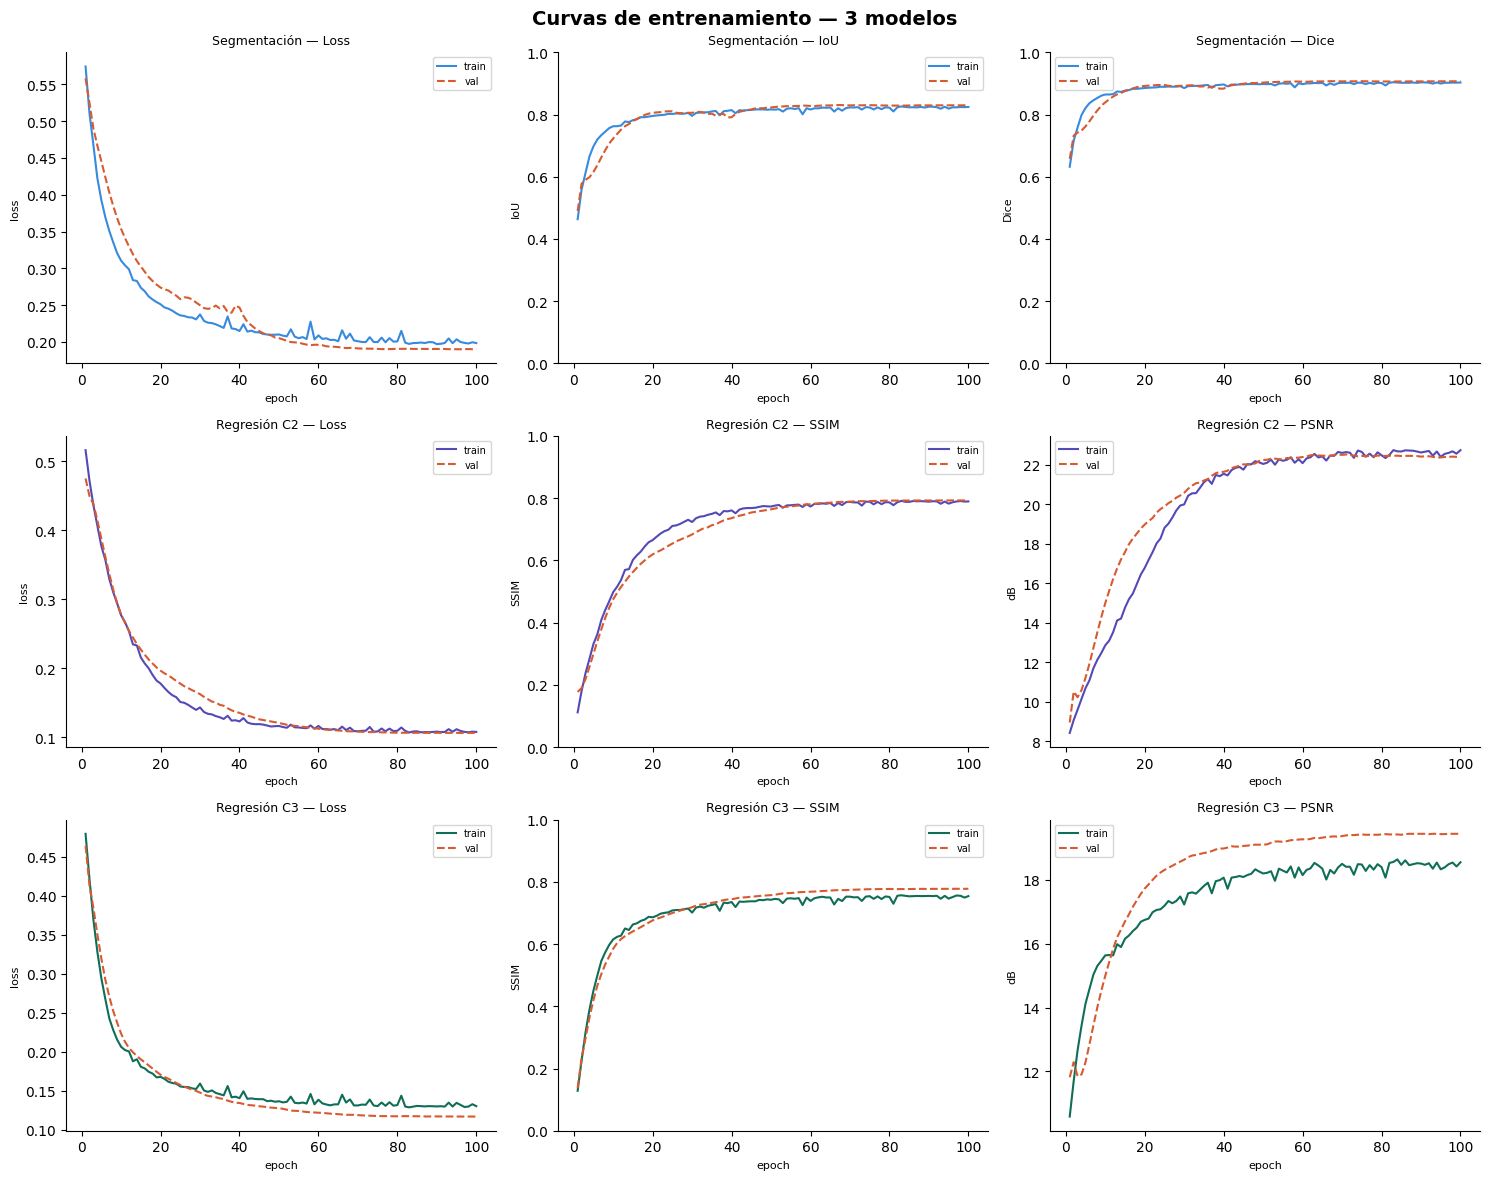

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Curvas de entrenamiento — 3 modelos', fontsize=14, fontweight='bold', y=0.98)

for row_i, (log, color, label, metrics) in enumerate([
    (seg_log, BLUE,   'Segmentación',
     [('train_loss','val_loss','Loss','loss',None),
      ('train_iou','val_iou','IoU','IoU',(0,1)),
      ('train_dice','val_dice','Dice','Dice',(0,1))]),
    (rc2_log, PURPLE, 'Regresión C2',
     [('train_loss','val_loss','Loss','loss',None),
      ('train_ssim','val_ssim','SSIM','SSIM',(0,1)),
      ('train_psnr','val_psnr','PSNR','dB',None)]),
    (rc3_log, TEAL,   'Regresión C3',
     [('train_loss','val_loss','Loss','loss',None),
      ('train_ssim','val_ssim','SSIM','SSIM',(0,1)),
      ('train_psnr','val_psnr','PSNR','dB',None)]),
]):
    if not log: continue
    epochs = [r['epoch'] for r in log]
    for col_i, (tk, vk, title, ylabel, ylim) in enumerate(metrics):
        ax = axes[row_i, col_i]
        ax.plot(epochs, [r.get(tk,0) for r in log], color=color,  lw=1.5, label='train')
        ax.plot(epochs, [r.get(vk,0) for r in log], color=ORANGE, lw=1.5, ls='--', label='val')
        ax.set_title(f'{label} — {title}', fontsize=9)
        ax.set_xlabel('epoch', fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Métricas de inferencia


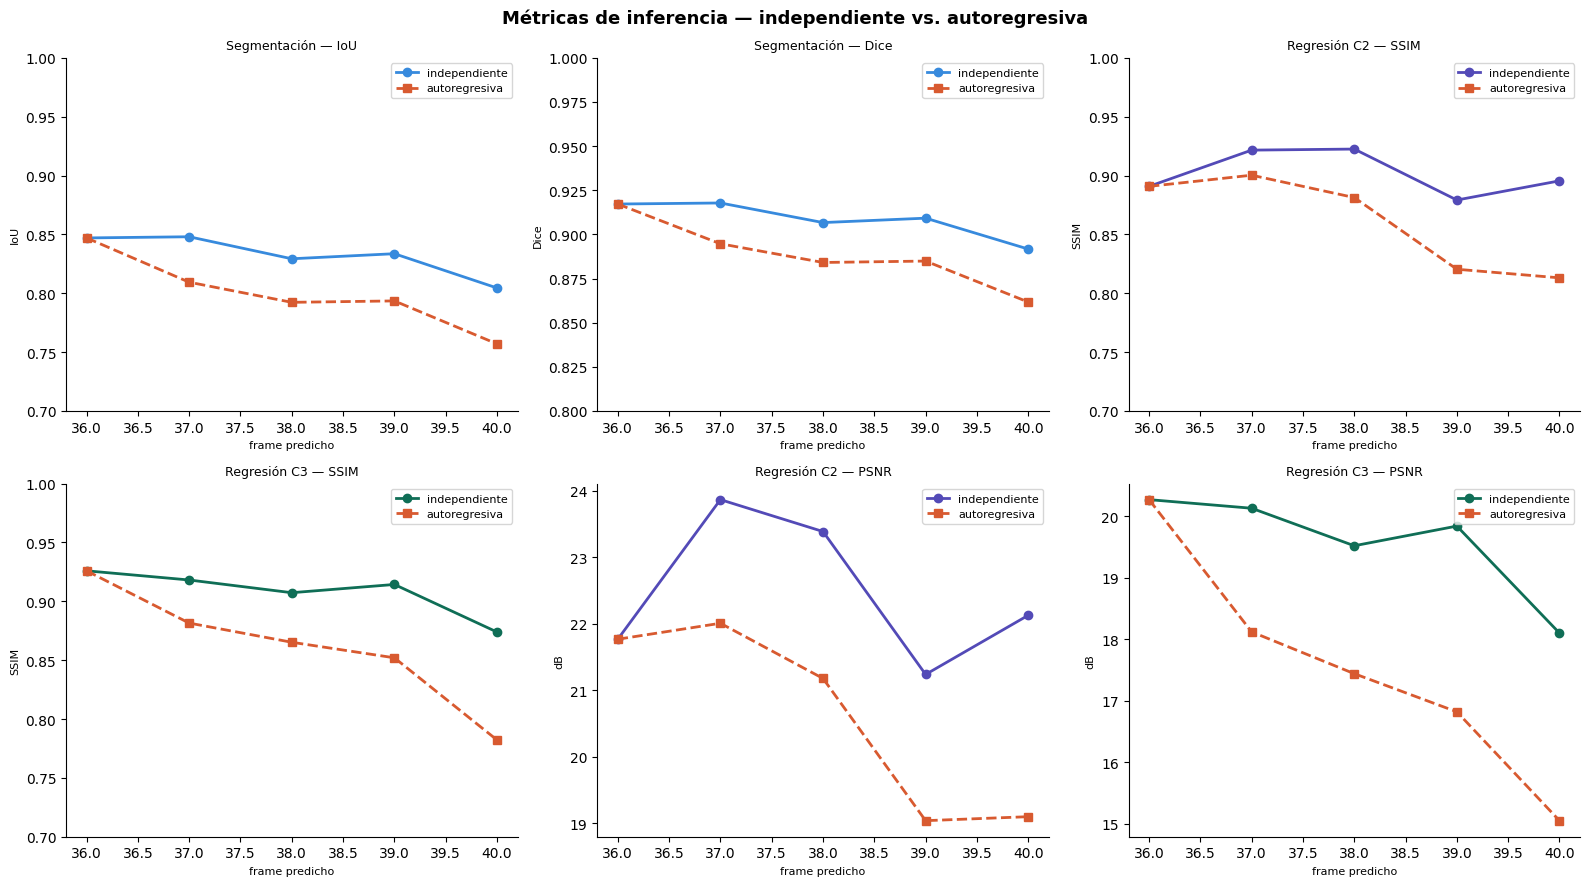

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Métricas de inferencia — independiente vs. autoregresiva',
             fontsize=13, fontweight='bold', y=0.98)

def frames_from(lst): return [int(r['pos_out']) for r in lst]
def vals_from(lst, k): return [r.get(k) for r in lst]

configs = [
    (axes[0,0], seg_i, seg_a, 'iou',  BLUE,   'Segmentación — IoU',  'IoU',  (0.7,1.0)),
    (axes[0,1], seg_i, seg_a, 'dice', BLUE,   'Segmentación — Dice', 'Dice', (0.8,1.0)),
    (axes[0,2], rc2_i, rc2_a, 'ssim', PURPLE, 'Regresión C2 — SSIM', 'SSIM', (0.7,1.0)),
    (axes[1,0], rc3_i, rc3_a, 'ssim', TEAL,   'Regresión C3 — SSIM', 'SSIM', (0.7,1.0)),
    (axes[1,1], rc2_i, rc2_a, 'psnr', PURPLE, 'Regresión C2 — PSNR', 'dB',   None),
    (axes[1,2], rc3_i, rc3_a, 'psnr', TEAL,   'Regresión C3 — PSNR', 'dB',   None),
]
for ax, li, la, key, color, title, ylabel, ylim in configs:
    if li: ax.plot(frames_from(li), vals_from(li,key), 'o-',  color=color,  lw=2, ms=6, label='independiente')
    if la: ax.plot(frames_from(la), vals_from(la,key), 's--', color=ORANGE, lw=2, ms=6, label='autoregresiva')
    ax.set_title(title, fontsize=9); ax.set_xlabel('frame predicho', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Visualización frame a frame


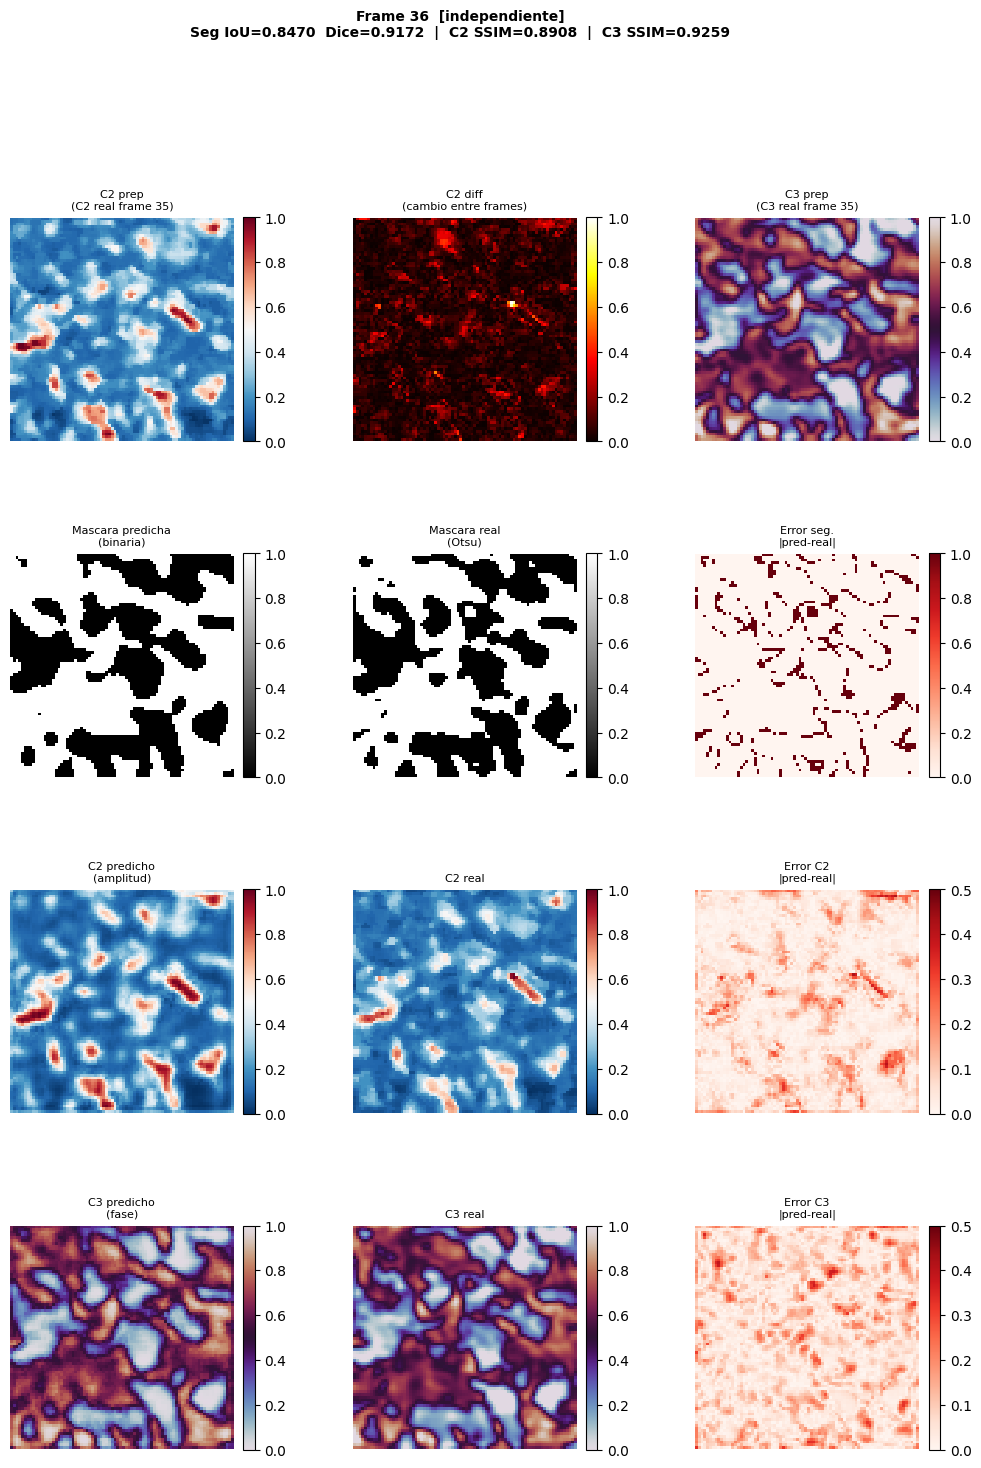

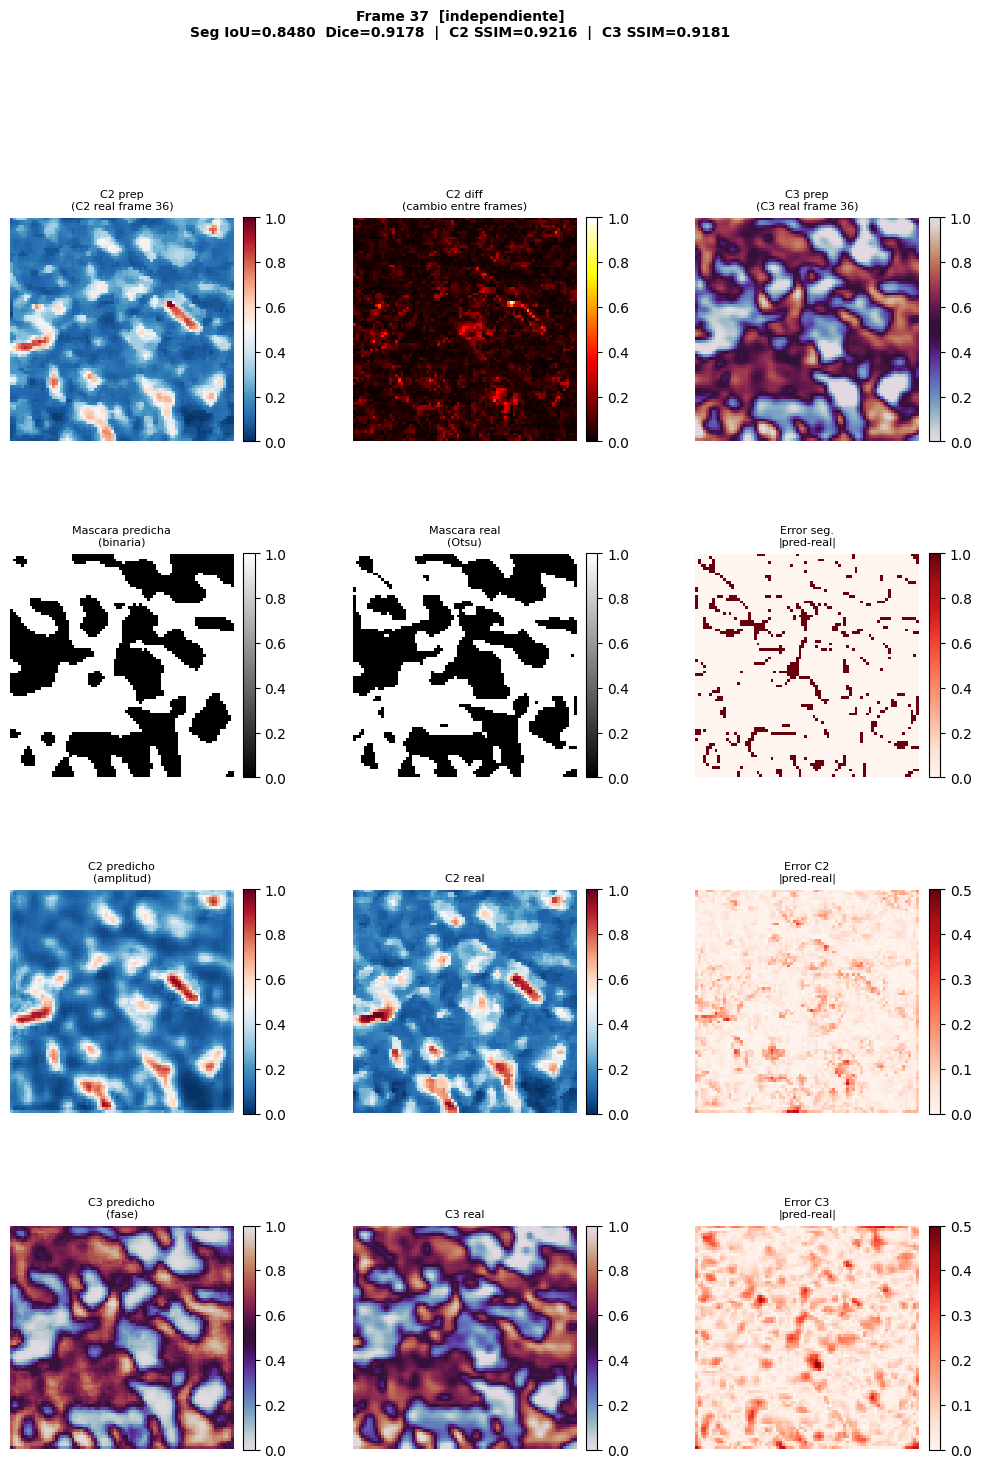

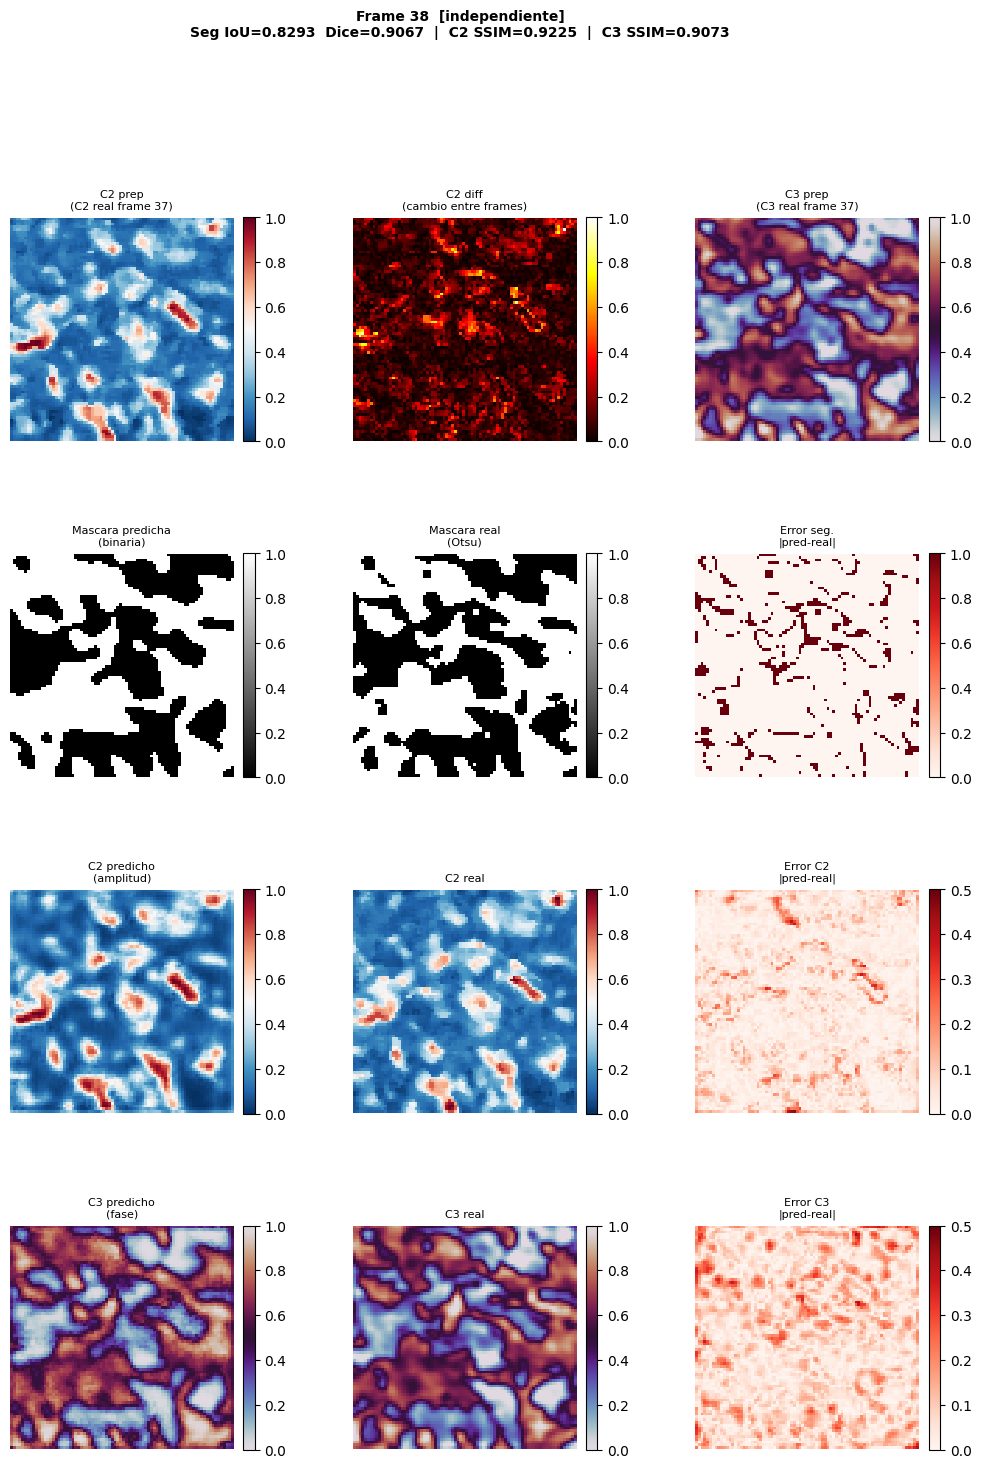

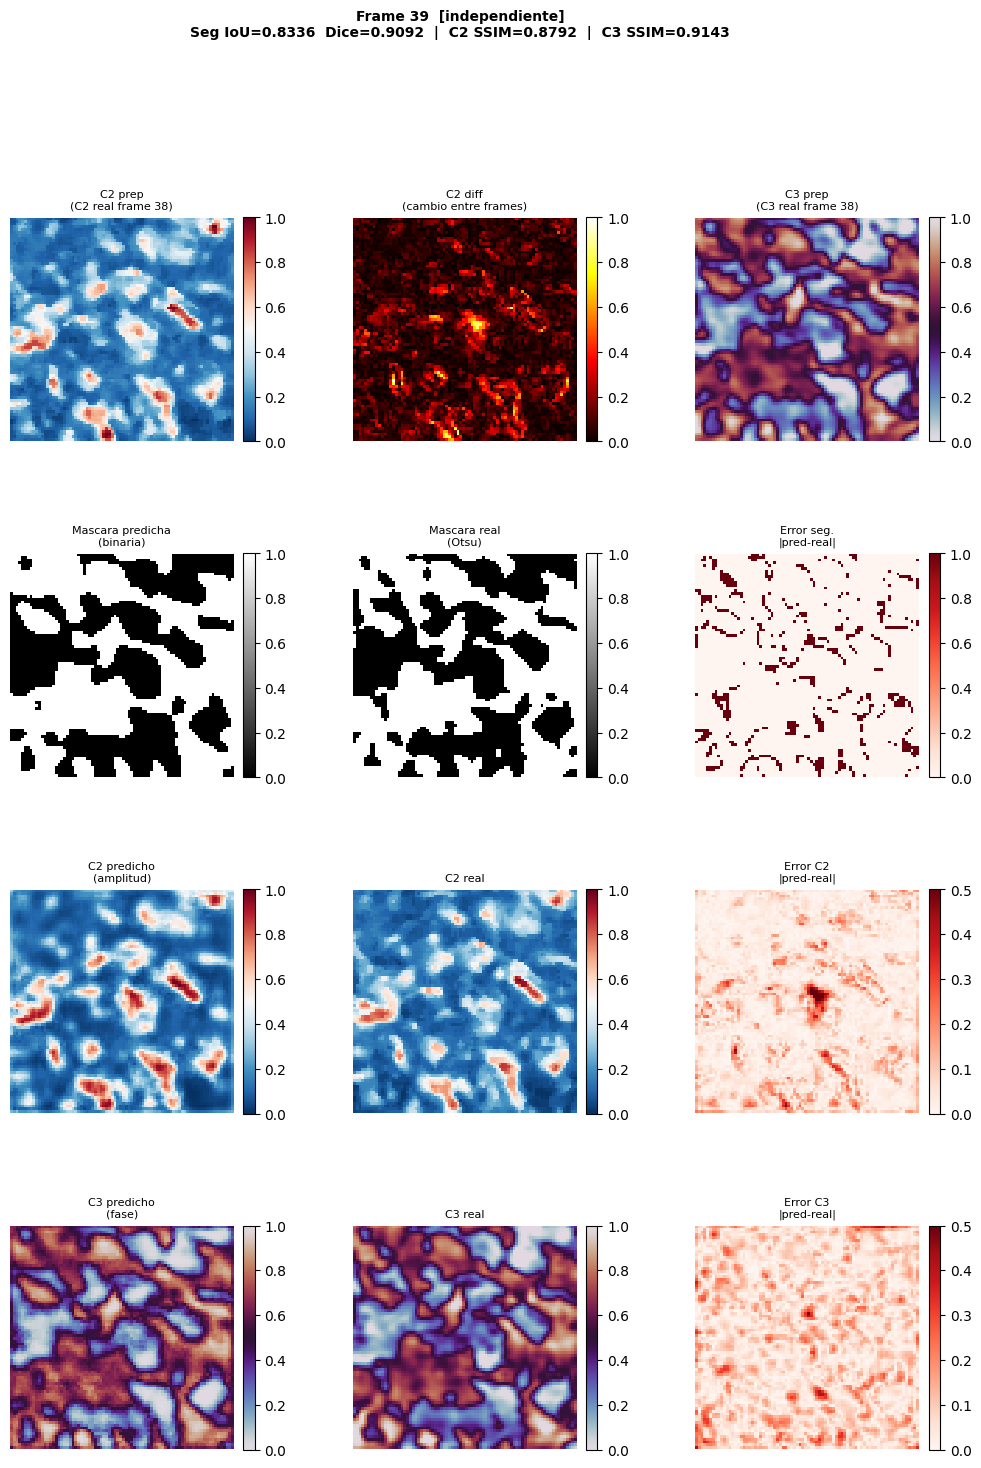

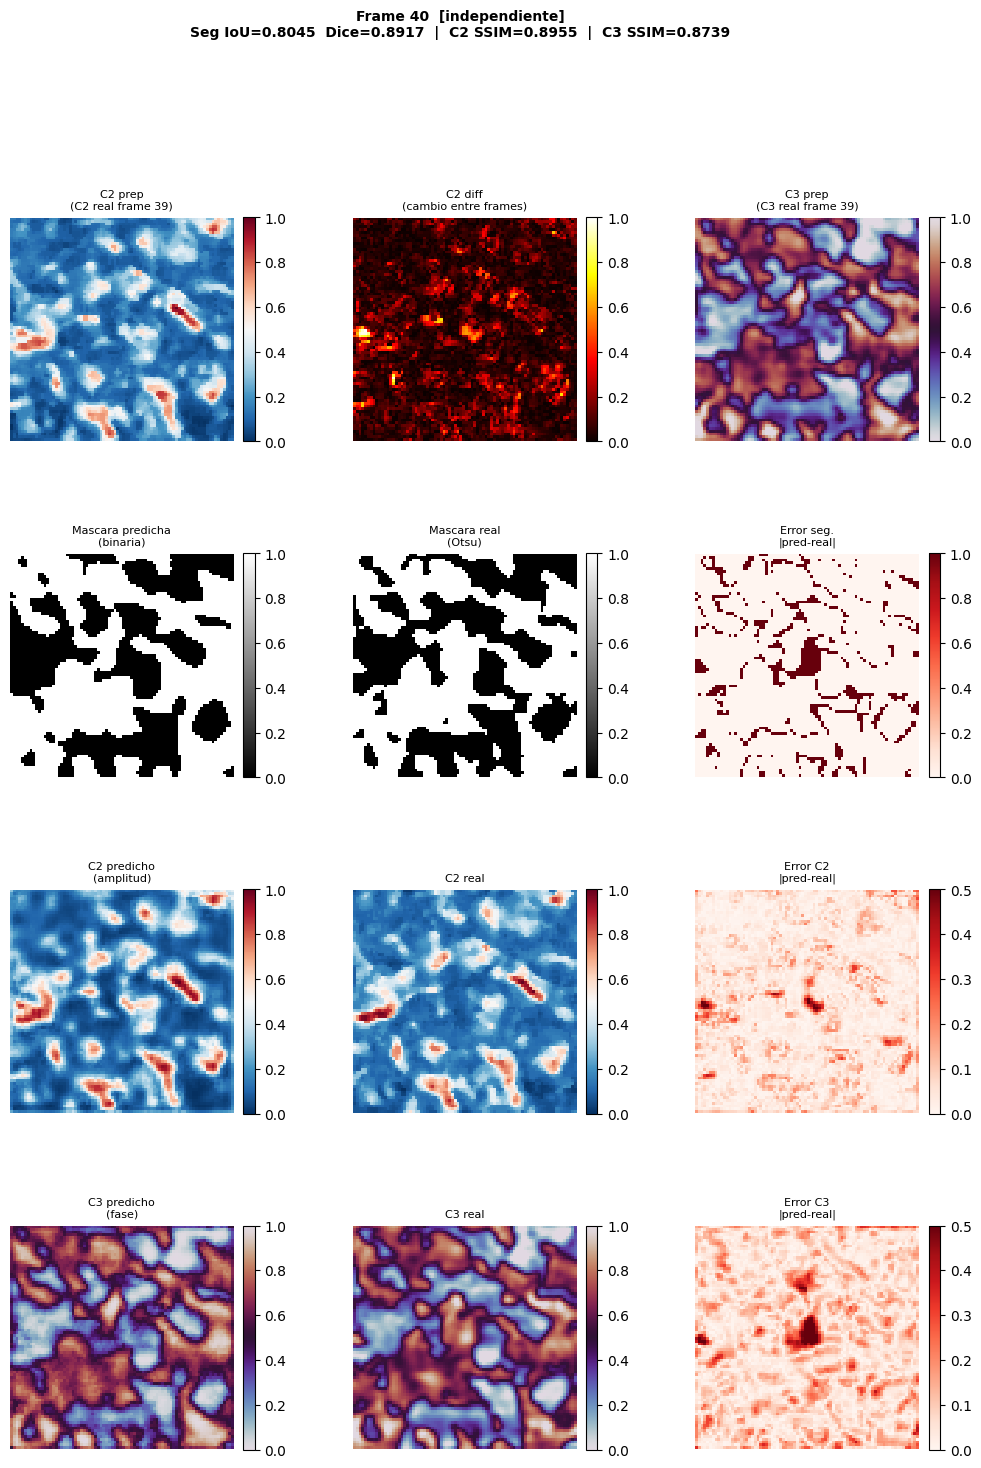

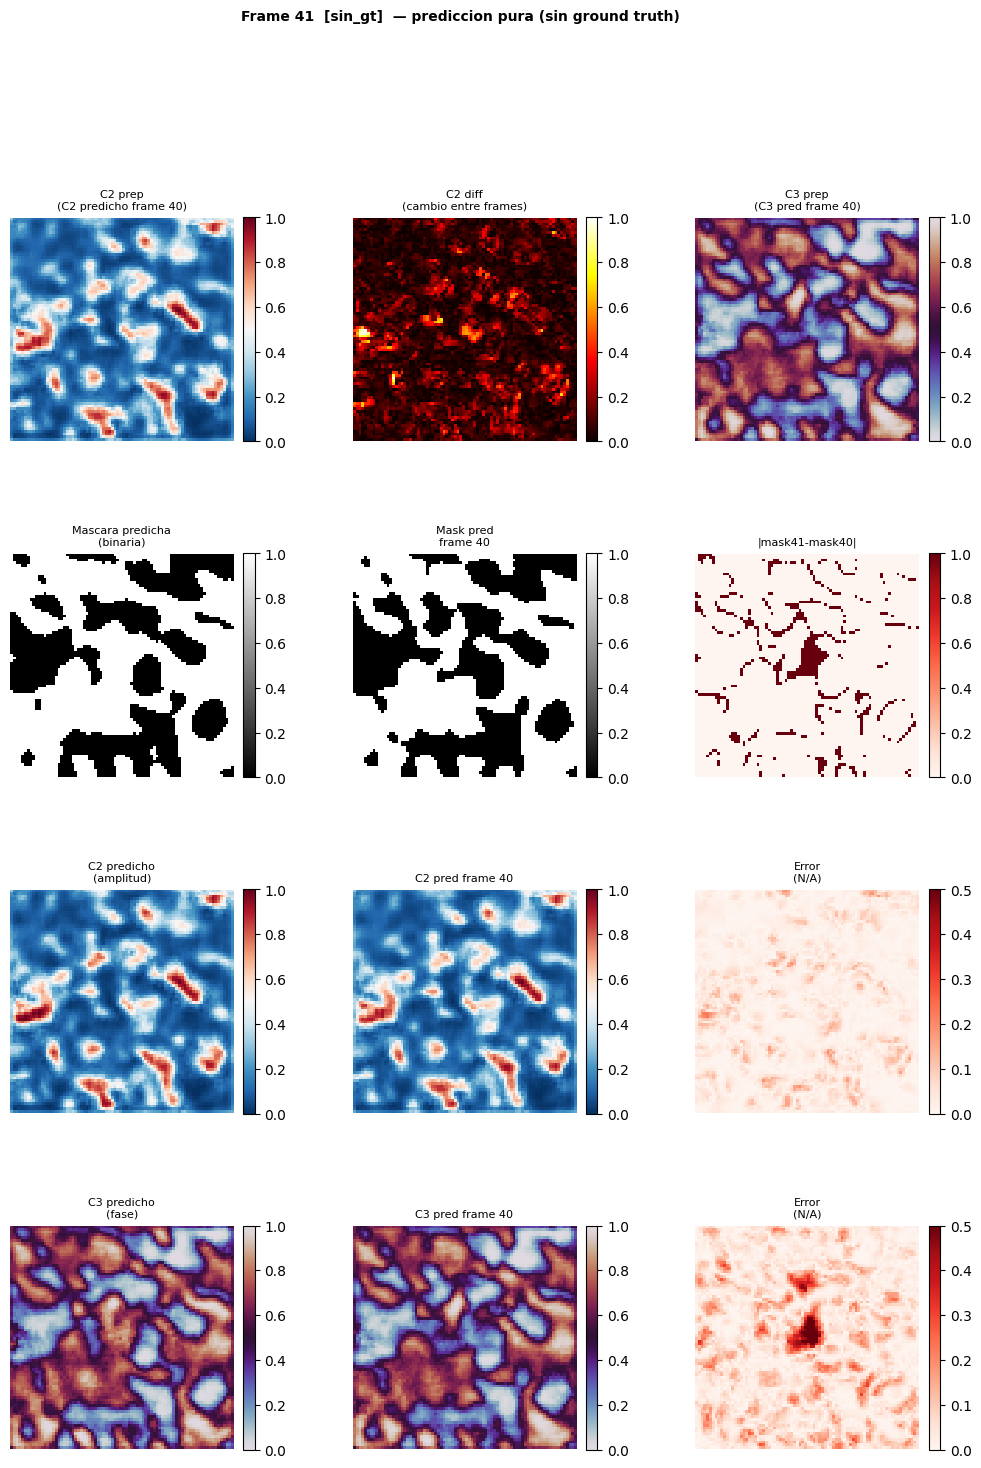

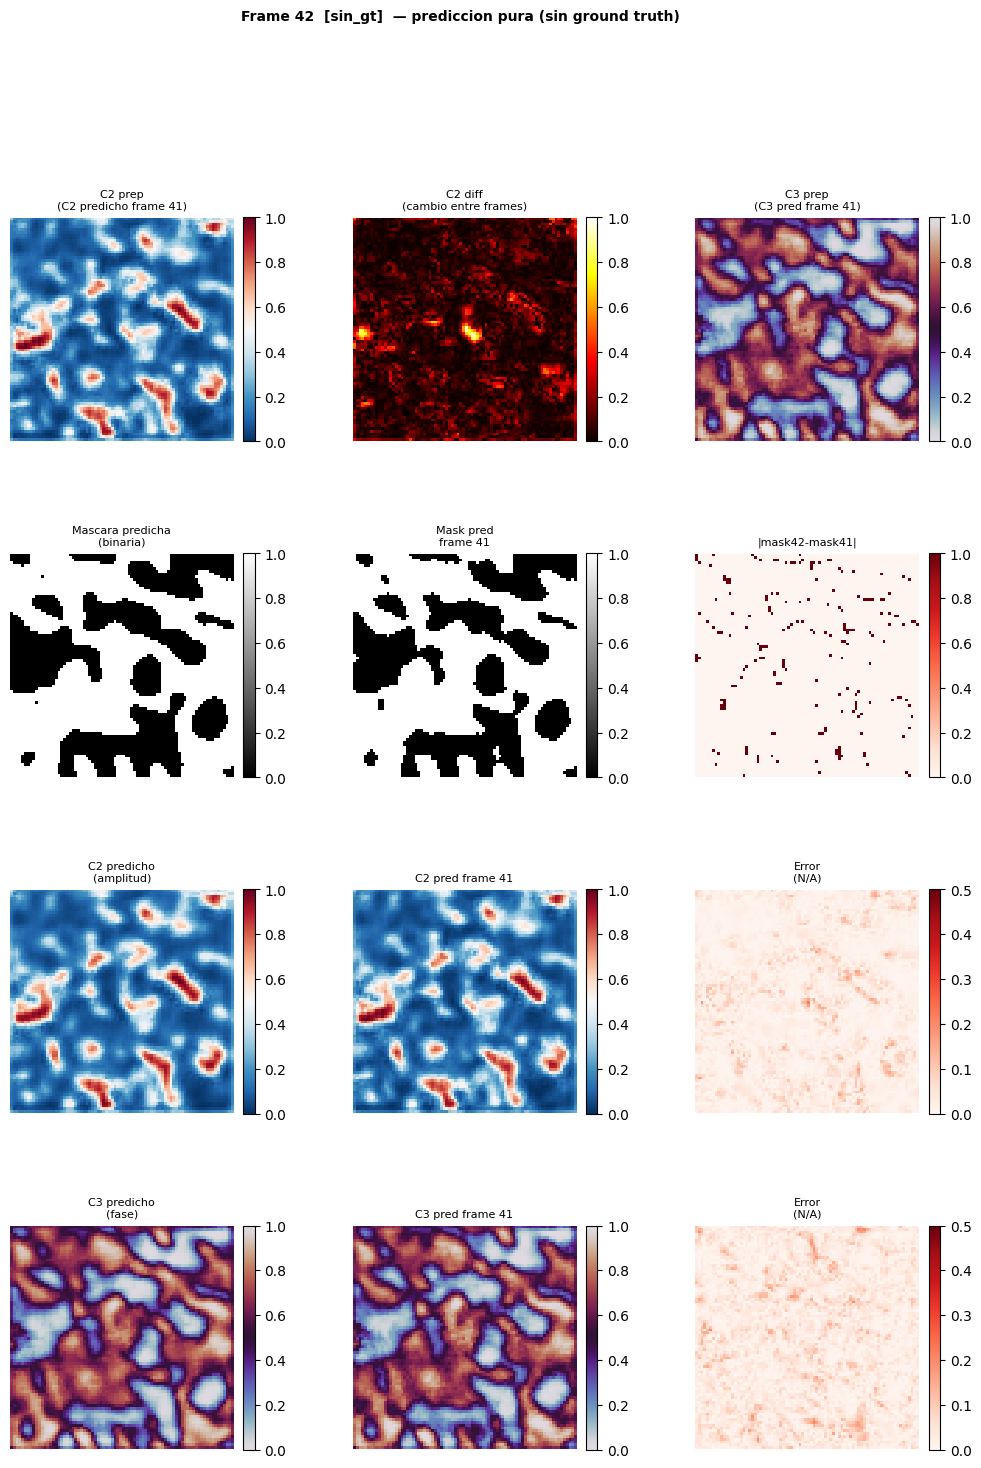

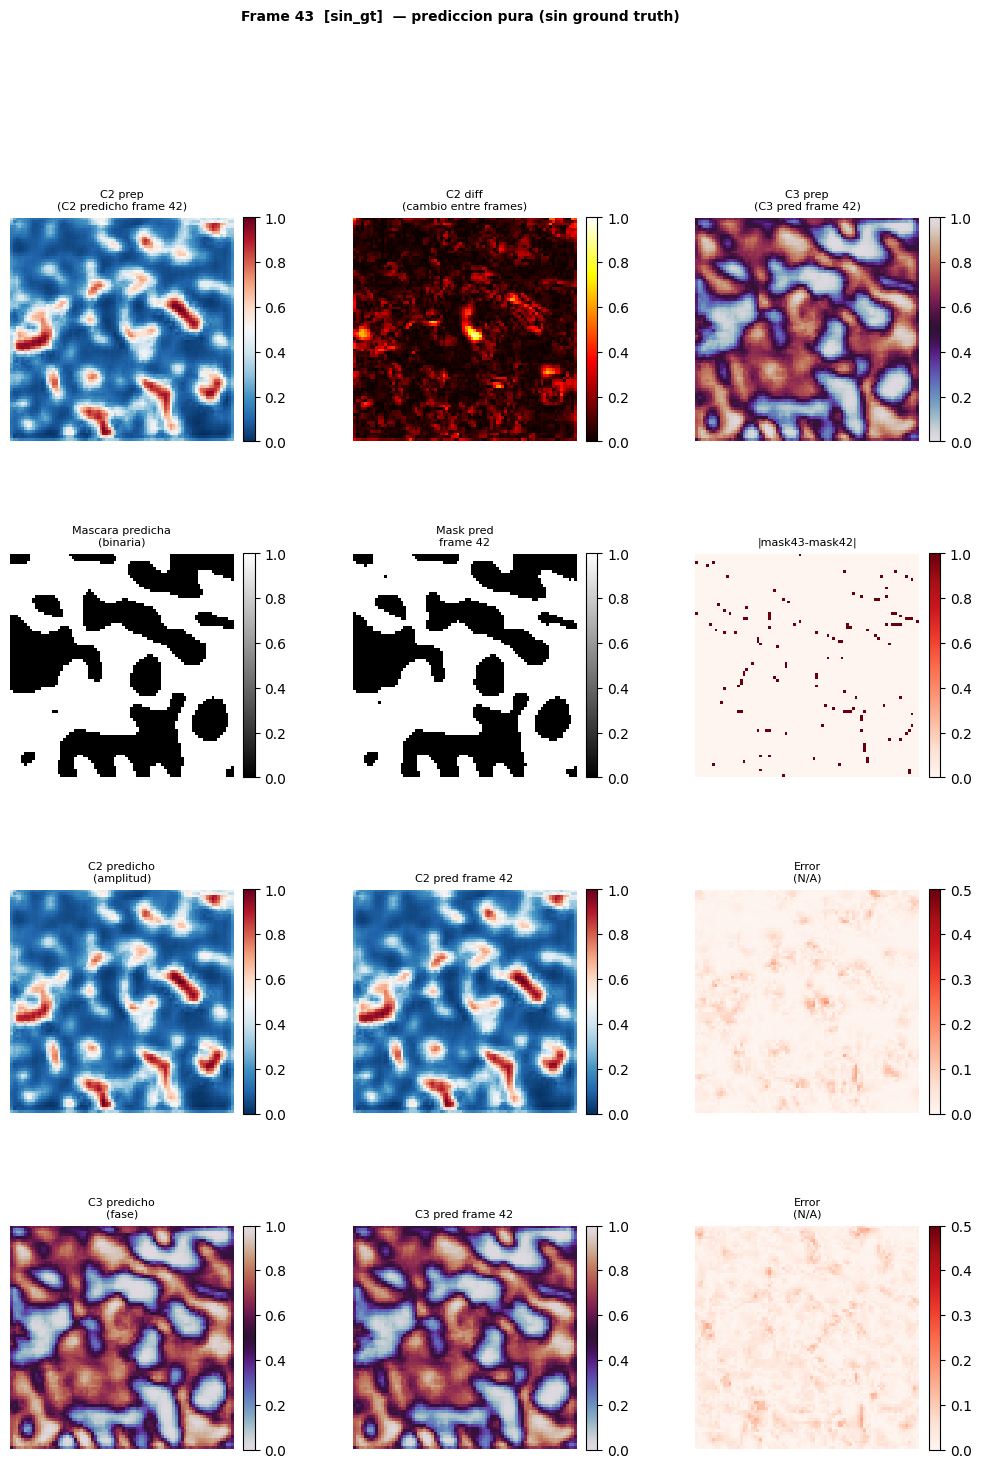

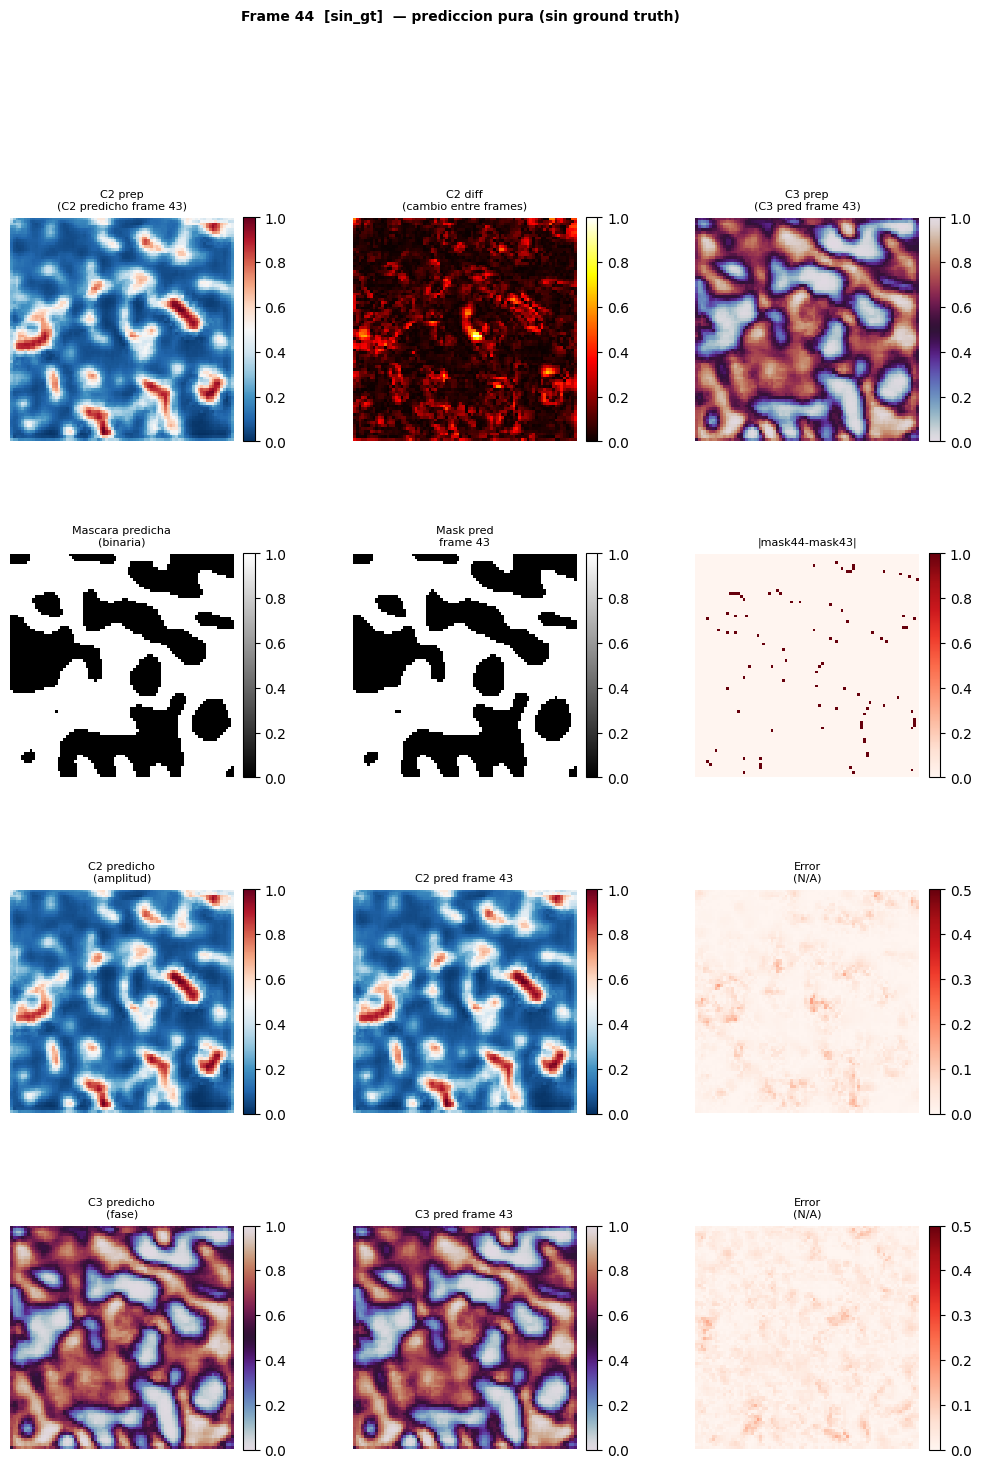

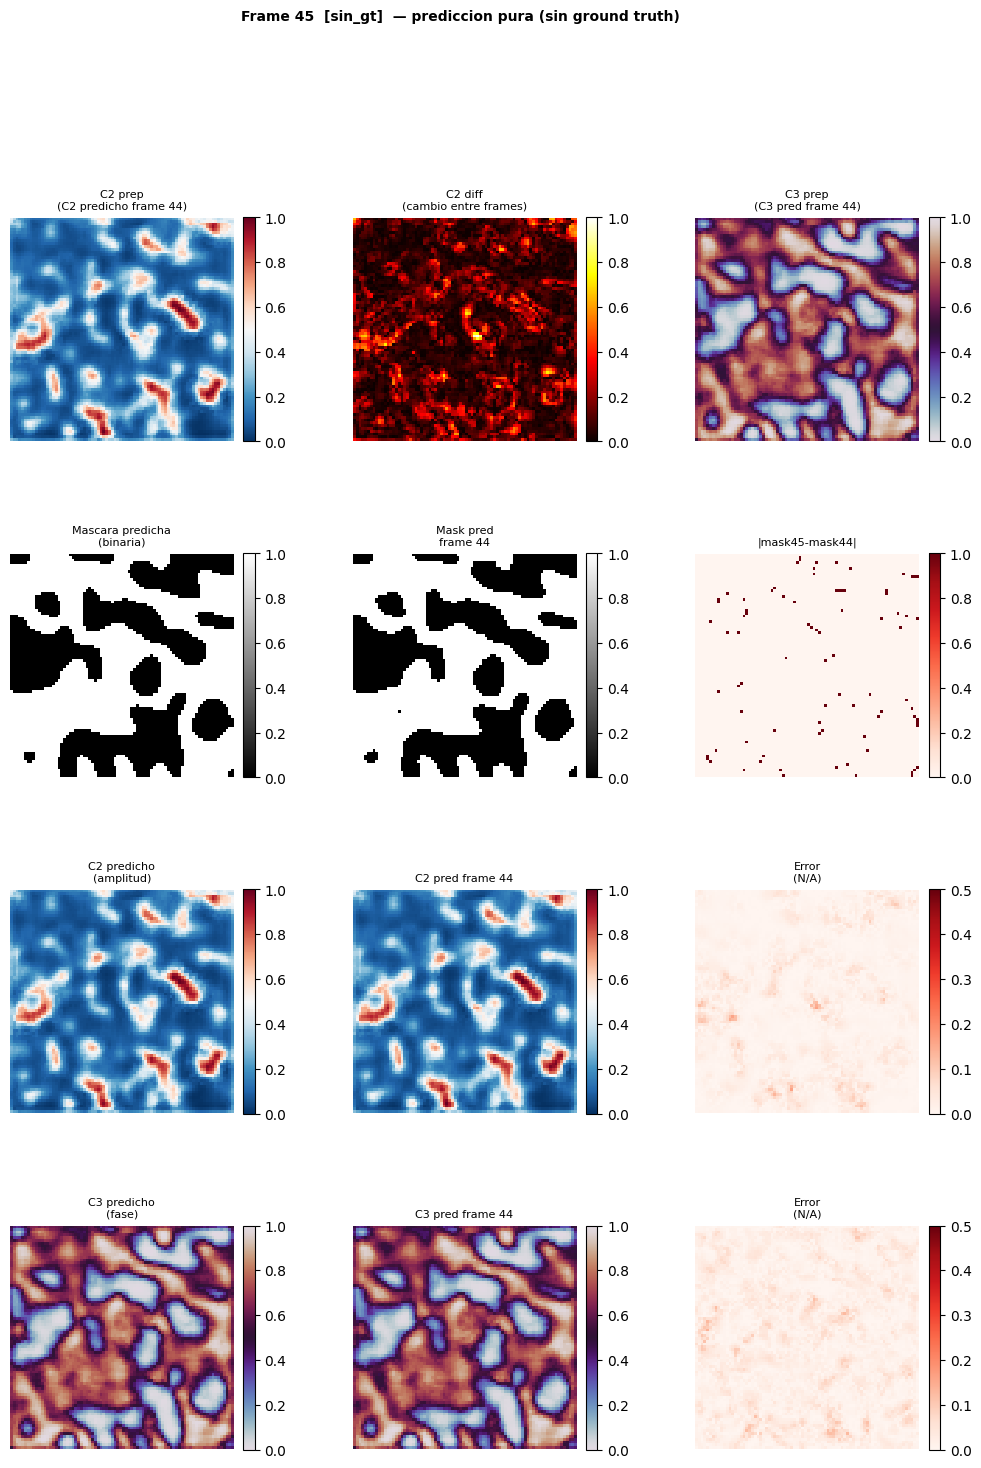

In [28]:
for fd in frames_data:
    fn     = fd['frame']
    has_gt = fd['has_gt']
    zeros  = np.zeros_like(fd['seg_pred']) if fd['seg_pred'] is not None else np.zeros((80,80))

    # Métricas del frame
    def _m(lst, fn, k):
        for r in lst:
            if int(r.get('pos_out',0)) == fn:
                v = r.get(k)
                return f'{float(v):.4f}' if v not in (None,'','None') else 'N/A'
        return 'N/A'

    if has_gt:
        titulo = (f'Frame {fn}  [{fd["modo"]}]\n'
                  f'Seg IoU={_m(seg_i,fn,"iou")}  Dice={_m(seg_i,fn,"dice")}  |  '
                  f'C2 SSIM={_m(rc2_i,fn,"ssim")}  |  C3 SSIM={_m(rc3_i,fn,"ssim")}')
    else:
        titulo = f'Frame {fn}  [{fd["modo"]}]  — prediccion pura (sin ground truth)'

    c2_prep, c2_diff, c3_prep, c2_fuente, c3_fuente, c3_cmap = cargar_inputs_frame(fn, has_gt=fd['has_gt'])

    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    fig.suptitle(titulo, fontsize=10, fontweight='bold', y=1.01)
    plt.subplots_adjust(hspace=0.5, wspace=0.4)

    # Fila 0 — Inputs
    for col, (data, title, cmap) in enumerate([
        (c2_prep, f'C2 prep\n({c2_fuente})',        'RdBu_r'),
        (c2_diff, 'C2 diff\n(cambio entre frames)', 'hot'),
        (c3_prep, f'C3 prep\n({c3_fuente})',        c3_cmap),
    ]):
        imshow_cb(axes[0,col], data, cmap, title)
    axes[0,0].set_ylabel(f'Input\nframe {fn-1}', fontsize=8, color=GRAY,
                          fontweight='bold', rotation=90, labelpad=40)

    # Fila 1 — Segmentación
    imshow_cb(axes[1,0], fd['seg_pred'], 'gray', 'Mascara predicha\n(binaria)')
    imshow_cb(axes[1,1], fd['seg_real'], 'gray',
              'Mascara real\n(Otsu)' if has_gt else f'Mask pred\nframe {fn-1}')
    imshow_cb(axes[1,2], fd['seg_error'], 'Reds',
              'Error seg.\n|pred-real|' if has_gt else f'|mask{fn}-mask{fn-1}|')
    axes[1,0].set_ylabel('Segmentacion', fontsize=8, color=BLUE, fontweight='bold',
                          rotation=90, labelpad=40)

    # Fila 2 — Regresión C2
    imshow_cb(axes[2,0], fd['rc2_pred'], 'RdBu_r', 'C2 predicho\n(amplitud)')
    imshow_cb(axes[2,1], fd['rc2_real'], 'RdBu_r',
              'C2 real' if has_gt else f'C2 pred frame {fn-1}')
    imshow_cb(axes[2,2], fd['rc2_error'], 'Reds',
              'Error C2\n|pred-real|' if has_gt else 'Error\n(N/A)', vmax=0.5)
    axes[2,0].set_ylabel('Regresion C2', fontsize=8, color=PURPLE, fontweight='bold',
                          rotation=90, labelpad=40)

    # Fila 3 — Regresión C3
    imshow_cb(axes[3,0], fd['rc3_pred'], 'twilight', 'C3 predicho\n(fase)')
    imshow_cb(axes[3,1], fd['rc3_real'], 'twilight',
              'C3 real' if has_gt else f'C3 pred frame {fn-1}')
    imshow_cb(axes[3,2], fd['rc3_error'], 'Reds',
              'Error C3\n|pred-real|' if has_gt else 'Error\n(N/A)', vmax=0.5)
    axes[3,0].set_ylabel('Regresion C3', fontsize=8, color=TEAL, fontweight='bold',
                          rotation=90, labelpad=40)

    plt.show()
    print()

## 7. Resúmenes por canal


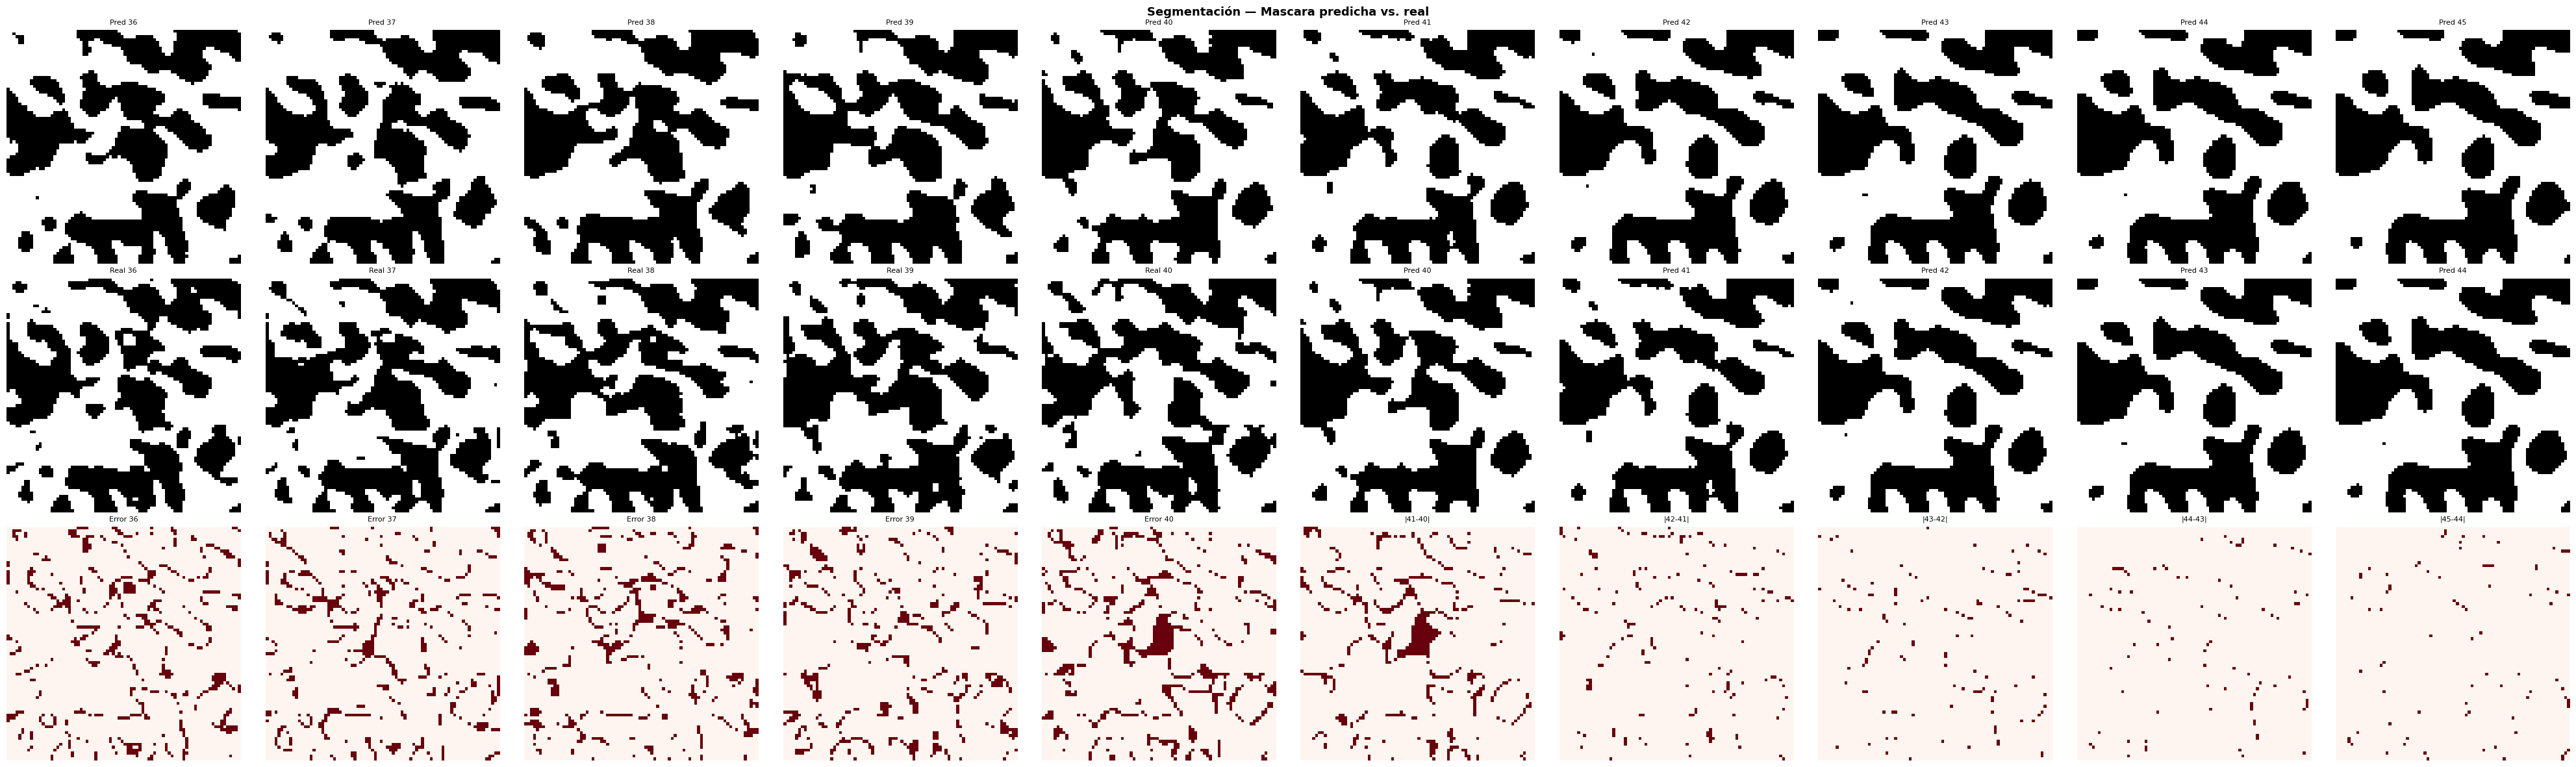

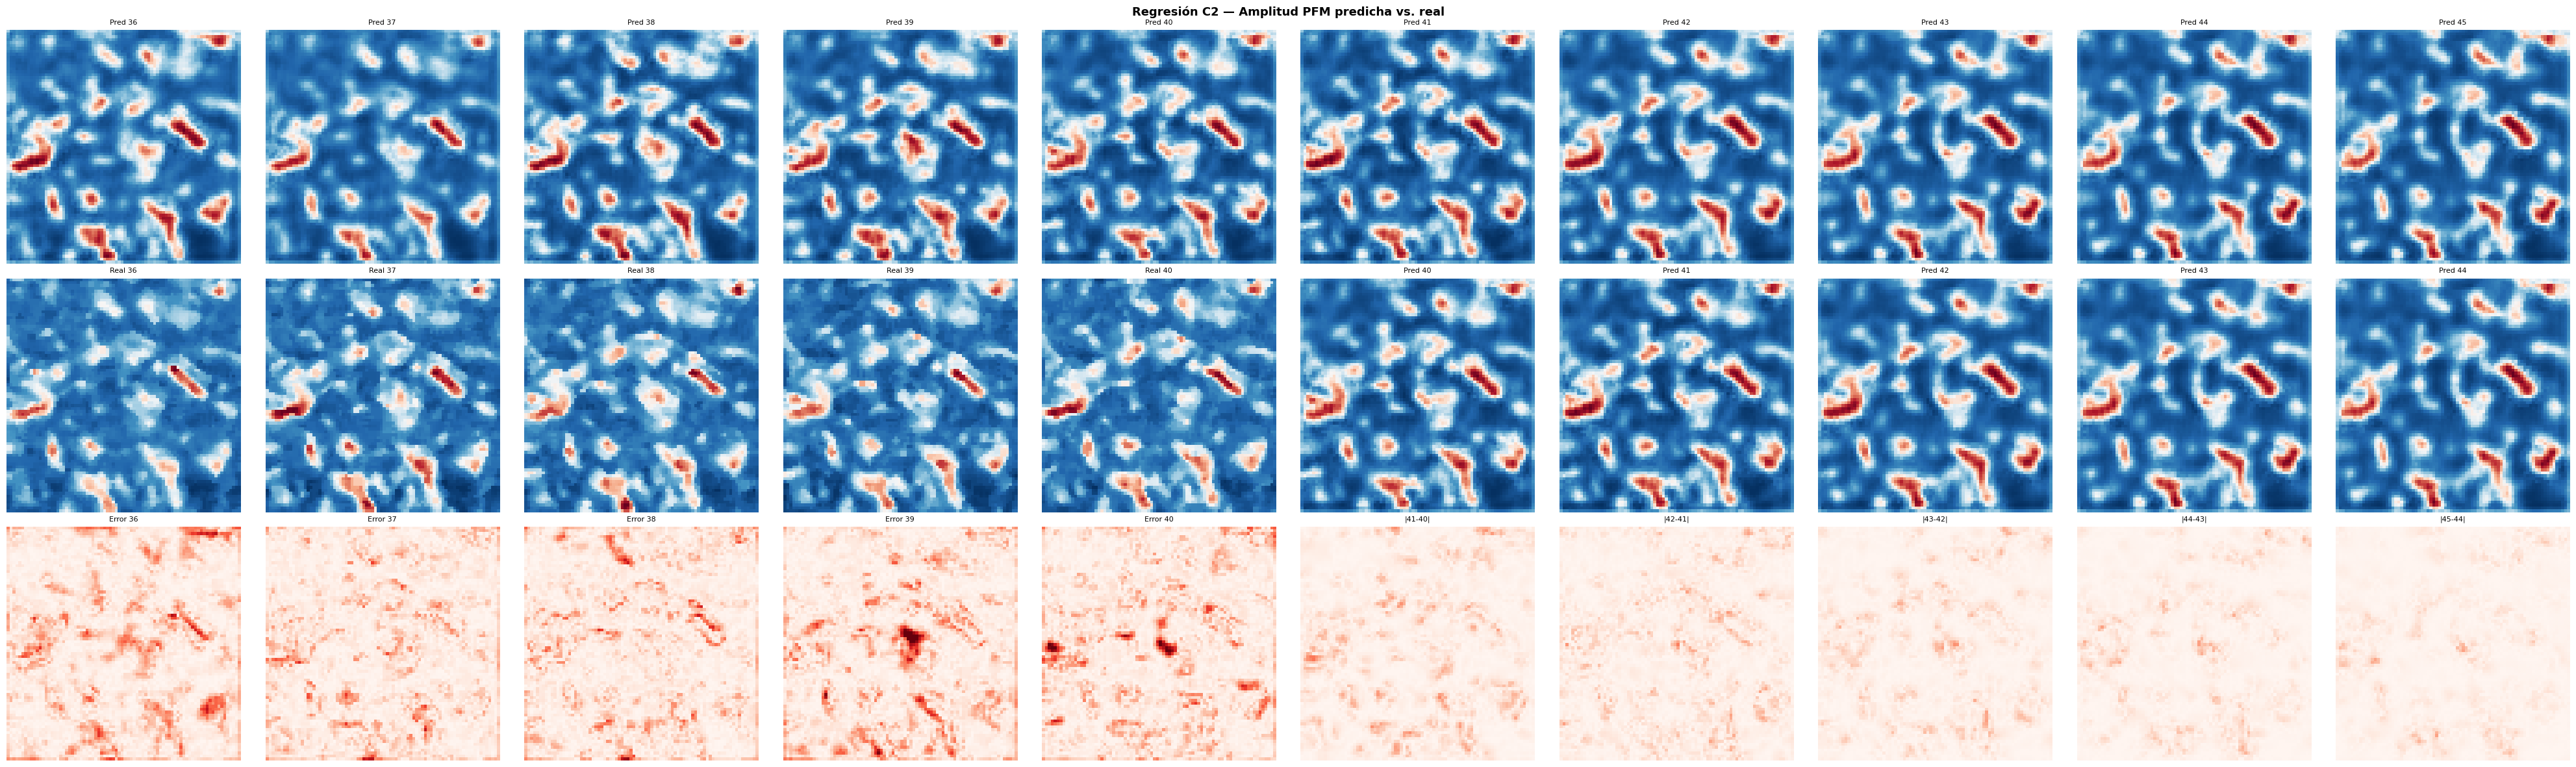

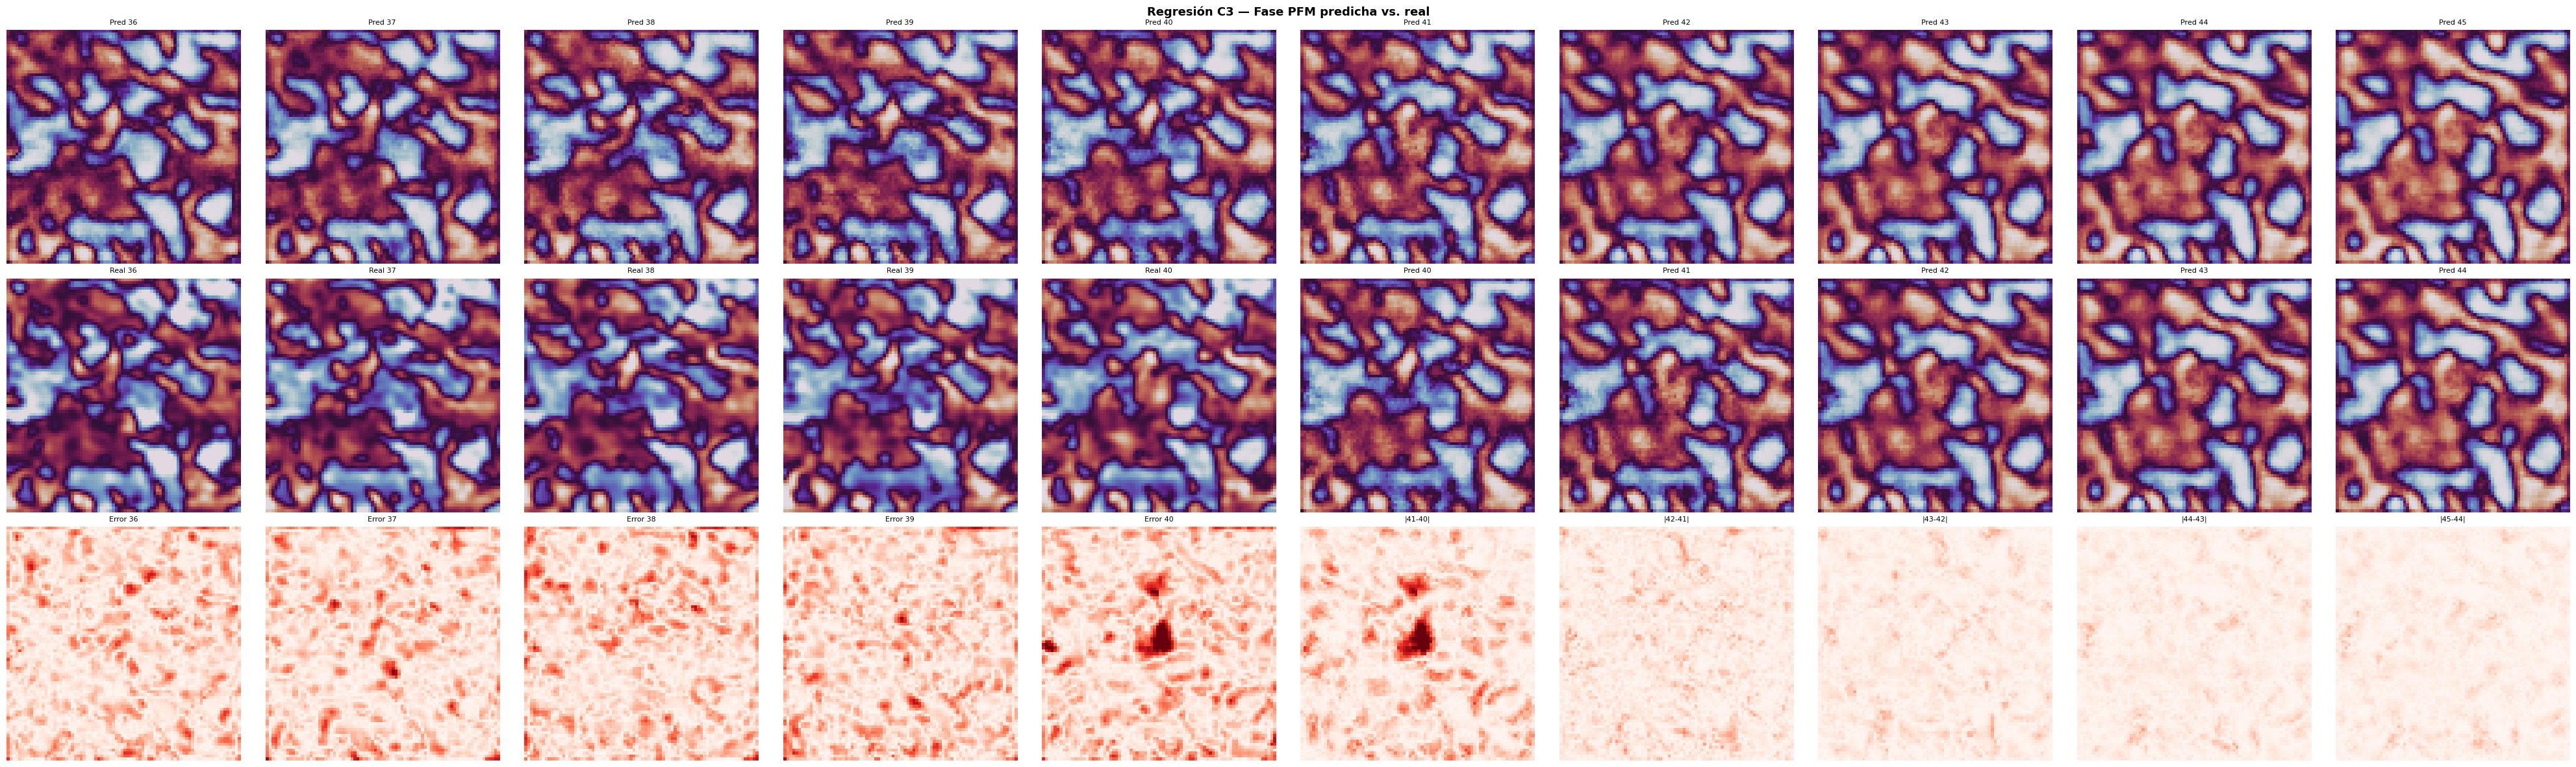

In [29]:
for modelo, cmap, color, label in [
    ('seg', 'gray',     BLUE,   'Segmentación — Mascara predicha vs. real'),
    ('rc2', 'RdBu_r',   PURPLE, 'Regresión C2 — Amplitud PFM predicha vs. real'),
    ('rc3', 'twilight', TEAL,   'Regresión C3 — Fase PFM predicha vs. real'),
]:
    n = len(frames_data)
    fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
    if n == 1: axes = axes.reshape(3,1)
    fig.suptitle(label, fontsize=13, fontweight='bold')

    for i, fd in enumerate(frames_data):
        fn = fd['frame']
        pred  = fd.get(f'{modelo}_pred')
        real  = fd.get(f'{modelo}_real')
        error = fd.get(f'{modelo}_error')
        has_gt= fd['has_gt']

        if pred is not None: axes[0,i].imshow(pred, cmap=cmap, vmin=0, vmax=1)
        axes[0,i].set_title(f'Pred {fn}', fontsize=8); axes[0,i].axis('off')

        ref_t = f'Real {fn}' if has_gt else f'Pred {fn-1}'
        if real is not None:
            axes[1,i].imshow(real, cmap=cmap, vmin=0, vmax=1)
        else:
            axes[1,i].set_facecolor('#EEEEEE')
            axes[1,i].text(0.5,0.5,'no disp.',ha='center',va='center',fontsize=7,
                           color='gray',transform=axes[1,i].transAxes)
        axes[1,i].set_title(ref_t, fontsize=8); axes[1,i].axis('off')

        err_t = f'Error {fn}' if has_gt else f'|{fn}-{fn-1}|'
        if error is not None:
            axes[2,i].imshow(error, cmap='Reds', vmin=0, vmax=0.5)
        else:
            axes[2,i].set_facecolor('#EEEEEE')
            axes[2,i].text(0.5,0.5,'no disp.',ha='center',va='center',fontsize=7,
                           color='gray',transform=axes[2,i].transAxes)
        axes[2,i].set_title(err_t, fontsize=8); axes[2,i].axis('off')

    for row, (lab, col) in enumerate([('Prediccion',color),('Real',color),('Error',ORANGE)]):
        axes[row,0].set_ylabel(lab, fontsize=9, fontweight='bold', color=col)

    plt.tight_layout()
    plt.show()

## 8. Análisis de error y degradación autoregresiva


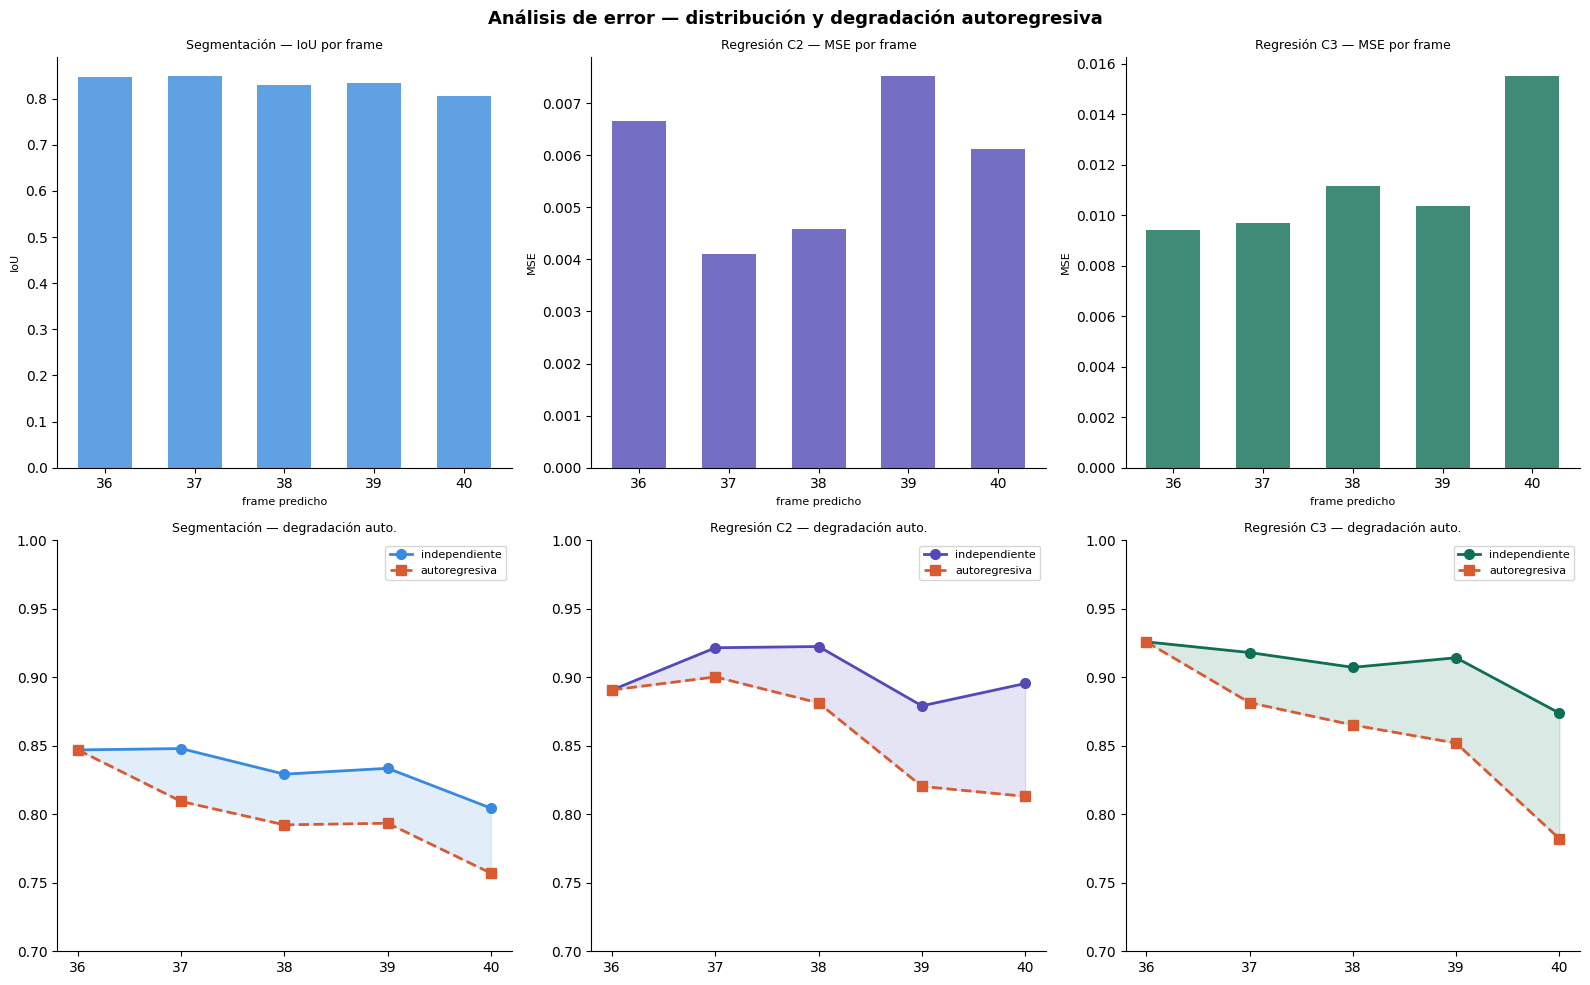

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis de error — distribución y degradación autoregresiva',
             fontsize=13, fontweight='bold', y=0.98)

def fs(lst): return [int(r['pos_out']) for r in lst]
def vs(lst, k): return [r.get(k) for r in lst]

# Fila 0 — Barras por frame
for ax, lst, key, color, title, ylabel in [
    (axes[0,0], seg_i, 'iou',  BLUE,   'Segmentación — IoU por frame',  'IoU'),
    (axes[0,1], rc2_i, 'mse',  PURPLE, 'Regresión C2 — MSE por frame',  'MSE'),
    (axes[0,2], rc3_i, 'mse',  TEAL,   'Regresión C3 — MSE por frame',  'MSE'),
]:
    if lst:
        axes_x = fs(lst); axes_y = vs(lst, key)
        ax.bar(axes_x, axes_y, color=color, alpha=0.8, width=0.6)
        ax.set_xticks(axes_x)
        ax.set_title(title, fontsize=9); ax.set_xlabel('frame predicho', fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Fila 1 — Degradación autoregresiva
for ax, li, la, key, color, title, ylabel in [
    (axes[1,0], seg_i, seg_a, 'iou',  BLUE,   'Segmentación — degradación auto.', 'IoU'),
    (axes[1,1], rc2_i, rc2_a, 'ssim', PURPLE, 'Regresión C2 — degradación auto.', 'SSIM'),
    (axes[1,2], rc3_i, rc3_a, 'ssim', TEAL,   'Regresión C3 — degradación auto.', 'SSIM'),
]:
    if li and la:
        xi = fs(li); yi = vs(li,key)
        xa = fs(la); ya = vs(la,key)
        ax.plot(xi, yi, 'o-',  color=color,  lw=2, ms=7, label='independiente')
        ax.plot(xa, ya, 's--', color=ORANGE, lw=2, ms=7, label='autoregresiva')
        ax.fill_between(xi, ya[:len(xi)], yi, alpha=0.15, color=color)
        ax.set_ylim(0.7, 1.0); ax.set_xticks(xi)
        ax.set_title(title, fontsize=9); ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Tabla de viabilidad


In [31]:
caida = lambda vi, va, k: (
    f"{abs((avg(va,k) or 0)-(avg(vi,k) or 0))*100:.1f}%" 
    if avg(vi,k) is not None and avg(va,k) is not None else 'N/A'
)
def ep(ckpt, key, fmt='.4f'):
    v = ckpt.get(key)
    return f'{float(v):{fmt}}' if isinstance(v,(int,float)) else 'N/A'

print("=" * 70)
print(f"{'MÉTRICA':<25} {'SEG indep':>10} {'SEG auto':>10} {'C2 indep':>10} {'C2 auto':>10} {'C3 indep':>10} {'C3 auto':>10}")
print("-" * 70)
rows = [
    ('IoU promedio',         avg_str(seg_i,'iou'),  avg_str(seg_a,'iou'),  '-','-','-','-'),
    ('Dice promedio',        avg_str(seg_i,'dice'), avg_str(seg_a,'dice'), '-','-','-','-'),
    ('SSIM promedio',        '-','-',  avg_str(rc2_i,'ssim'), avg_str(rc2_a,'ssim'), avg_str(rc3_i,'ssim'), avg_str(rc3_a,'ssim')),
    ('PSNR promedio (dB)',   '-','-',  avg_str(rc2_i,'psnr','.2f'), avg_str(rc2_a,'psnr','.2f'), avg_str(rc3_i,'psnr','.2f'), avg_str(rc3_a,'psnr','.2f')),
    ('Mejor epoch (train)',  str(int(seg_ckpt.get('epoch',0))) if seg_ckpt.get('epoch') else 'N/A', '-', str(int(rc2_ckpt.get('epoch',0))) if rc2_ckpt.get('epoch') else 'N/A', '-', str(int(rc3_ckpt.get('epoch',0))) if rc3_ckpt.get('epoch') else 'N/A', '-'),
    ('Val IoU/SSIM (train)', ep(seg_ckpt,'val_iou'),'-', ep(rc2_ckpt,'val_ssim'),'-', ep(rc3_ckpt,'val_ssim'),'-'),
    ('Caída autoregresiva',  caida(seg_i,seg_a,'iou'),'-', caida(rc2_i,rc2_a,'ssim'),'-', caida(rc3_i,rc3_a,'ssim'),'-'),
]
for r in rows:
    print(f"{r[0]:<25} {r[1]:>10} {r[2]:>10} {r[3]:>10} {r[4]:>10} {r[5]:>10} {r[6]:>10}")
print("=" * 70)

MÉTRICA                    SEG indep   SEG auto   C2 indep    C2 auto   C3 indep    C3 auto
----------------------------------------------------------------------
IoU promedio                  0.8325     0.7998          -          -          -          -
Dice promedio                 0.9085     0.8885          -          -          -          -
SSIM promedio                      -          -     0.9019     0.8612     0.9079     0.8614
PSNR promedio (dB)                 -          -      22.48      20.62      19.57      17.54
Mejor epoch (train)               67          -         96          -        100          -
Val IoU/SSIM (train)          0.8305          -     0.7930          -     0.7778          -
Caída autoregresiva             3.3%          -       4.1%          -       4.6%          -
